In [466]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [467]:
data= pd.read_csv('patient_data.csv')
data.head()

,C,Age,History,Patient,TakeMedication,Severity,BreathShortness,VisualChanges,NoseBleeding,Whendiagnoused,Systolic,Diastolic,ControlledDiet,Stages
0,Male,18-34,Yes,No,No,Mild,No,No,No,<1 Year,111 - 120,81 - 90,No,HYPERTENSION (Stage-1)
1,Female,18-34,Yes,No,No,Mild,No,No,No,<1 Year,111 - 120,81 - 90,No,HYPERTENSION (Stage-1)
2,Male,35-50,Yes,No,No,Mild,No,No,No,<1 Year,111 - 120,81 - 90,No,HYPERTENSION (Stage-1)
3,Female,35-50,Yes,No,No,Mild,No,No,No,<1 Year,111 - 120,81 - 90,No,HYPERTENSION (Stage-1)
4,Male,51-64,Yes,No,No,Mild,No,No,No,<1 Year,111 - 120,81 - 90,No,HYPERTENSION (Stage-1)


In [468]:
data.isnull().sum()

C                  0
Age                0
History            0
Patient            0
TakeMedication     0
Severity           0
BreathShortness    0
VisualChanges      0
NoseBleeding       0
Whendiagnoused     0
Systolic           0
Diastolic          0
ControlledDiet     0
Stages             0
dtype: int64

In [469]:
data.rename(columns={'C':"Gender"}, inplace=True)

In [470]:
data.head()


,Gender,Age,History,Patient,TakeMedication,Severity,BreathShortness,VisualChanges,NoseBleeding,Whendiagnoused,Systolic,Diastolic,ControlledDiet,Stages
0,Male,18-34,Yes,No,No,Mild,No,No,No,<1 Year,111 - 120,81 - 90,No,HYPERTENSION (Stage-1)
1,Female,18-34,Yes,No,No,Mild,No,No,No,<1 Year,111 - 120,81 - 90,No,HYPERTENSION (Stage-1)
2,Male,35-50,Yes,No,No,Mild,No,No,No,<1 Year,111 - 120,81 - 90,No,HYPERTENSION (Stage-1)
3,Female,35-50,Yes,No,No,Mild,No,No,No,<1 Year,111 - 120,81 - 90,No,HYPERTENSION (Stage-1)
4,Male,51-64,Yes,No,No,Mild,No,No,No,<1 Year,111 - 120,81 - 90,No,HYPERTENSION (Stage-1)


In [471]:
data['TakeMedication'].replace({'Yes': 'Yes'}, inplace=True)
data['NoseBleeding'].replace({'No': 'No'}, inplace=True)
data['Systolic'].replace({'121-130': '121 - 130'}, inplace=True)
data['Systolic'].replace({'100+': '100 - 110'}, inplace=True)
data['Stages'].replace({'HYPERTENSION (Stage-2).': 'HYPERTENSION (Stage-2)'}, inplace=True)
data['Stages'].replace({'HYPERTENSIVE CRISI': 'HYPERTENSIVE CRISIS'}, inplace=True)
print((data['Diastolic'] == '130+').sum())
print((data['Diastolic'] == '100+').sum())
data['Diastolic'].replace({'130+': '100+'}, inplace=True)

4
237


C:\Users\gupta\AppData\Local\Temp\ipykernel_9776\1866944744.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['TakeMedication'].replace({'Yes': 'Yes'}, inplace=True)
C:\Users\gupta\AppData\Local\Temp\ipykernel_9776\1866944744.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy

In [472]:
print(data.duplicated().sum())
477
data.drop_duplicates (inplace=True)

477


CATEGORICAL ENCODING

In [473]:
data.head()

,Gender,Age,History,Patient,TakeMedication,Severity,BreathShortness,VisualChanges,NoseBleeding,Whendiagnoused,Systolic,Diastolic,ControlledDiet,Stages
0,Male,18-34,Yes,No,No,Mild,No,No,No,<1 Year,111 - 120,81 - 90,No,HYPERTENSION (Stage-1)
1,Female,18-34,Yes,No,No,Mild,No,No,No,<1 Year,111 - 120,81 - 90,No,HYPERTENSION (Stage-1)
2,Male,35-50,Yes,No,No,Mild,No,No,No,<1 Year,111 - 120,81 - 90,No,HYPERTENSION (Stage-1)
3,Female,35-50,Yes,No,No,Mild,No,No,No,<1 Year,111 - 120,81 - 90,No,HYPERTENSION (Stage-1)
4,Male,51-64,Yes,No,No,Mild,No,No,No,<1 Year,111 - 120,81 - 90,No,HYPERTENSION (Stage-1)


In [474]:
nominal_features = ["Gender","History"	,"Patient"	,"TakeMedication"	,"BreathShortness"	,"VisualChanges"	,"NoseBleeding"	,"ControlledDiet"	,]
ordinal_features =[f for f in data.columns if f not in nominal_features]
ordinal_features.remove("Stages")
print(nominal_features)
print(ordinal_features)

['Gender', 'History', 'Patient', 'TakeMedication', 'BreathShortness', 'VisualChanges', 'NoseBleeding', 'ControlledDiet']
['Age', 'Severity', 'Whendiagnoused', 'Systolic', 'Diastolic']


In [475]:
# Encode nominal (binary) features
for col in nominal_features:
    if set(data[col].unique()) == {"Yes", "No"}:
        data[col] = data[col].map({"No": 0, "Yes": 1})
    elif col == 'Gender':
        data[col] = data[col].map({'Male': 0, 'Female': 1})


# Encode ordinal features

data['Age'] = data['Age'].map({
    '18-34': 1,
    '35-50': 2,
    '51-64': 3,
    '65+': 4
})

data['Severity'] = data['Severity'].map({
    'Mild': 0,
    'Moderate': 1,
    'Severe': 2
})

data['Whendiagnoused'] = data['Whendiagnoused'].map({
    '<1 Year': 3,
    '1-5 Years': 2,
    '>5 Years': 1
})

data['Systolic'] = data['Systolic'].map({
    '100 - 110': 0,
    '111 - 120': 1,
    '121 - 130': 2,
    '130+': 3
})

data['Diastolic'] = data['Diastolic'].map({
    '70 - 80': 0,
    '81 - 90': 1,
    '91 - 100': 2,
    '100+': 3
})


# Encode target variable

data['Stages'] = data['Stages'].map({
    'NORMAL': 0,
    'HYPERTENSION (Stage-1)': 1,
    'HYPERTENSION (Stage-2)': 2,
    'HYPERTENSIVE CRISIS': 3
})

In [476]:
data['Systolic'] = data['Systolic'].fillna(data['Systolic'].mean())
data['Diastolic'] = data['Diastolic'].fillna(data['Diastolic'].mean())

data['Stages'] = data['Stages'].fillna(data['Systolic'].mean())


In [477]:
data.head(50)

,Gender,Age,History,Patient,TakeMedication,Severity,BreathShortness,VisualChanges,NoseBleeding,Whendiagnoused,Systolic,Diastolic,ControlledDiet,Stages
0,0,1,1,0,No,0.0,0,0,No,3.0,1.000000,1,0,1
1,1,1,1,0,No,0.0,0,0,No,3.0,1.000000,1,0,1
2,0,2,1,0,No,0.0,0,0,No,3.0,1.000000,1,0,1
3,1,2,1,0,No,0.0,0,0,No,3.0,1.000000,1,0,1
4,0,3,1,0,No,0.0,0,0,No,3.0,1.000000,1,0,1
5,1,3,1,0,No,0.0,0,0,No,3.0,1.000000,1,0,1
6,0,4,1,0,No,0.0,0,0,No,3.0,1.000000,1,0,1
7,1,4,1,0,No,0.0,0,0,No,3.0,1.000000,1,0,1
8,0,1,1,0,No,NaN,0,0,No,3.0,1.000000,1,0,1
9,0,2,1,1,Yes,NaN,1,1,No,3.0,1.533203,2,1,2


In [478]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
data[ordinal_features] = scaler.fit_transform(data[ordinal_features])

In [479]:
# data['Gender'] = data['Gender'].map({0:'Male',1:'Female'})

In [480]:
data.head()

,Gender,Age,History,Patient,TakeMedication,Severity,BreathShortness,VisualChanges,NoseBleeding,Whendiagnoused,Systolic,Diastolic,ControlledDiet,Stages
0,0,0.000000,1,0,No,0.0,0,0,No,1.0,0.333333,0.333333,0,1
1,1,0.000000,1,0,No,0.0,0,0,No,1.0,0.333333,0.333333,0,1
2,0,0.333333,1,0,No,0.0,0,0,No,1.0,0.333333,0.333333,0,1
3,1,0.333333,1,0,No,0.0,0,0,No,1.0,0.333333,0.333333,0,1
4,0,0.666667,1,0,No,0.0,0,0,No,1.0,0.333333,0.333333,0,1


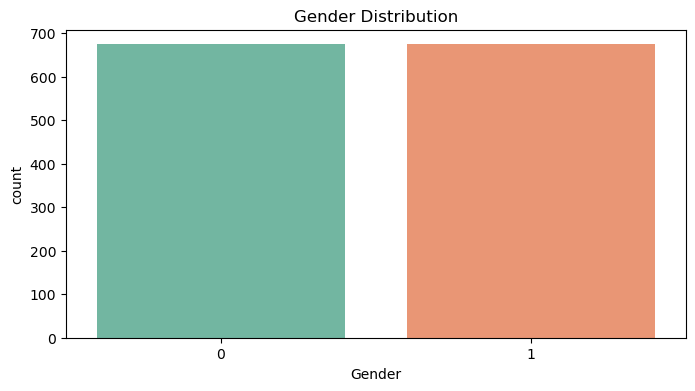

In [481]:
plt.figure(figsize=(8,4))
sns.countplot(data=data, x="Gender", hue="Gender", palette="Set2", legend=False)
plt.title("Gender Distribution")
plt.show()

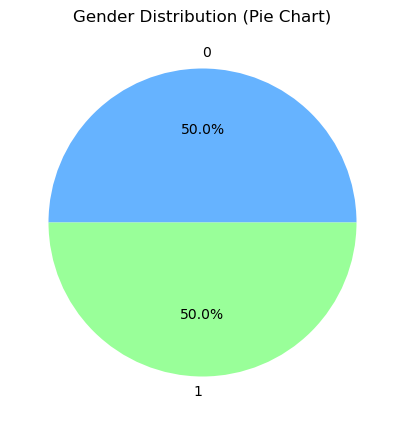

In [482]:
#Pie chart for Gender
data['Gender'].value_counts().plot.pie(autopct= '%1.1f%%', figsize=(5,5), colors=['#66b3ff', '#99ff99'])
plt.title("Gender Distribution (Pie Chart)")
plt.ylabel("")
plt.show()

C:\Users\gupta\AppData\Local\Temp\ipykernel_9776\1695634405.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x="Stages", palette="coolwarm")


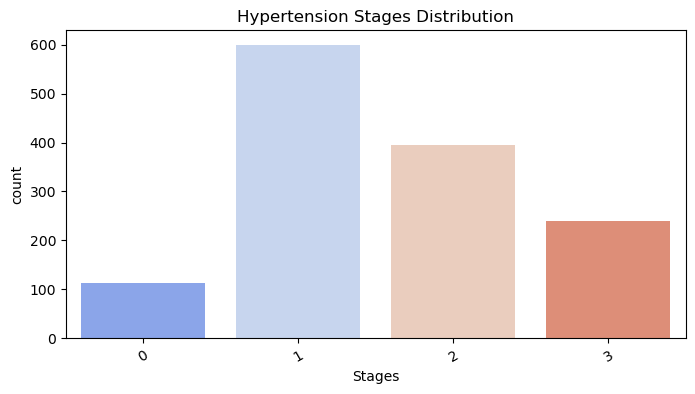

In [483]:
plt.figure(figsize=(8,4))
sns.countplot(data=data, x="Stages", palette="coolwarm")
plt.title("Hypertension Stages Distribution")
plt.xticks(rotation=30)
plt.show()

In [484]:
print(data[['Systolic','Diastolic']].head(50))

    Systolic  Diastolic
0   0.333333   0.333333
1   0.333333   0.333333
2   0.333333   0.333333
3   0.333333   0.333333
4   0.333333   0.333333
5   0.333333   0.333333
6   0.333333   0.333333
7   0.333333   0.333333
8   0.333333   0.333333
9   0.511068   0.666667
10  0.511068   0.666667
11  0.511068   0.666667
12  0.511068   0.666667
13  0.511068   0.666667
14  0.511068   0.666667
15  0.511068   0.666667
16  0.511068   0.666667
17  1.000000   1.000000
18  0.333333   0.333333
19  0.333333   0.333333
20  0.333333   0.333333
21  0.333333   0.333333
22  0.333333   0.333333
23  1.000000   1.000000
24  1.000000   1.000000
25  1.000000   1.000000
26  1.000000   1.000000
27  1.000000   1.000000
28  1.000000   1.000000
29  1.000000   1.000000
30  1.000000   1.000000
31  1.000000   1.000000
32  1.000000   1.000000
33  0.511068   0.666667
34  0.511068   0.666667
35  0.511068   0.666667
36  0.511068   0.666667
37  0.511068   0.666667
38  0.511068   0.666667
39  0.511068   0.666667
40  0.511068   0

In [485]:
print(data[['Systolic','Diastolic']].corr())

           Systolic  Diastolic
Systolic   1.000000   0.324031
Diastolic  0.324031   1.000000


In [486]:
print(data['Systolic'].unique())
print(data['Diastolic'].unique())

[0.33333333 0.51106771 1.         0.         0.66666667]
[0.33333333 0.66666667 1.         0.        ]


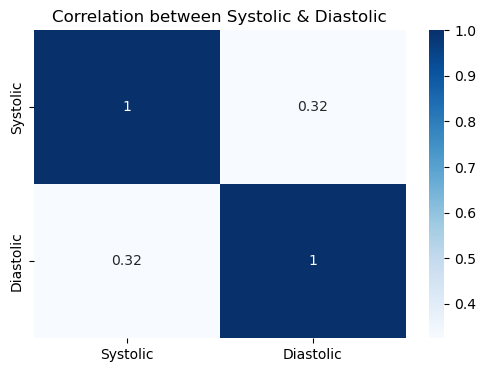

In [487]:


# Convert BP ranges to midpoint values
# dHeatmap on encoded numeric BP only (after midpoint conversion)

# def range_to_midpoint(val):
#     if "-" in val:
#         start, end = val.split("-")
#         return (int(start.strip()) + int(end.strip())) / 2
#     elif "+" in val:
#         return int(val.replace("+", "").strip())
#     else:
#         return np.nan

# data['Systolic_num'] = data['Systolic'].apply(range_to_midpoint)
# data['Diastolic_num'] = data['Diastolic'].apply(range_to_midpoint)
plt.figure(figsize=(6, 4))
sns.heatmap(data[['Systolic', 'Diastolic']].corr(), annot=True, cmap="Blues")
plt.title("Correlation between Systolic & Diastolic")
plt.show()

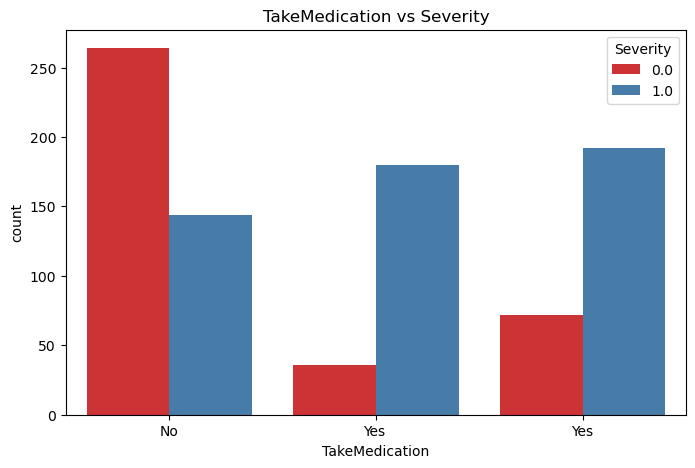

In [488]:
# Relationship: TakeMedication vs Severity
plt.figure(figsize=(8,5))
sns.countplot(data=data, x="TakeMedication", hue="Severity", palette="Set1")
plt.title("TakeMedication vs Severity")
plt.show()

In [489]:
print(data["Age"].unique())

[0.         0.33333333 0.66666667 1.        ]


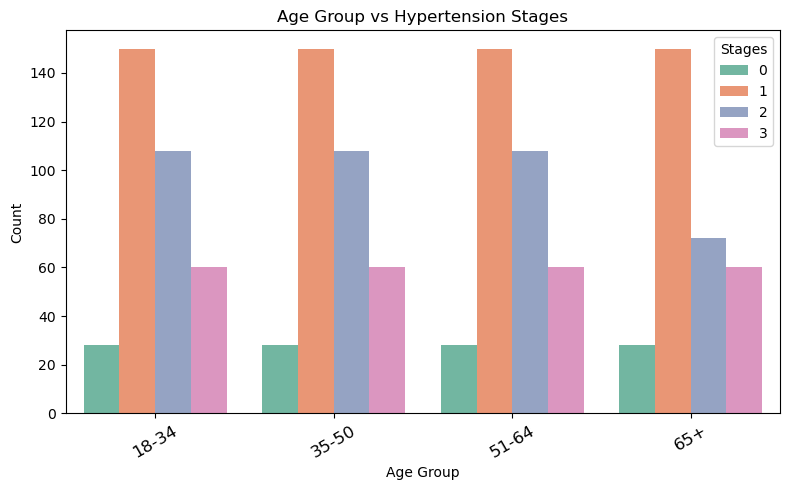

In [490]:
# Round Age values to avoid floating precision issues
data["Age"] = data["Age"].round(3)

# Age group vs Stages
data["Age_group"] = data["Age"].map({
    0.0: "18-34",
    0.333: "35-50",
    0.667: "51-64",
    1.0: "65+"
})

plt.figure(figsize=(8,5))
sns.countplot(data=data, x="Age_group", hue="Stages", palette="Set2")

plt.title("Age Group vs Hypertension Stages")
plt.xlabel("Age Group")
plt.ylabel("Count")

plt.xticks(fontsize=12, rotation=30)
plt.tight_layout()

plt.show()

In [491]:
print(data["Systolic"].unique())
print(data["Diastolic"].unique())

[0.33333333 0.51106771 1.         0.         0.66666667]
[0.33333333 0.66666667 1.         0.        ]


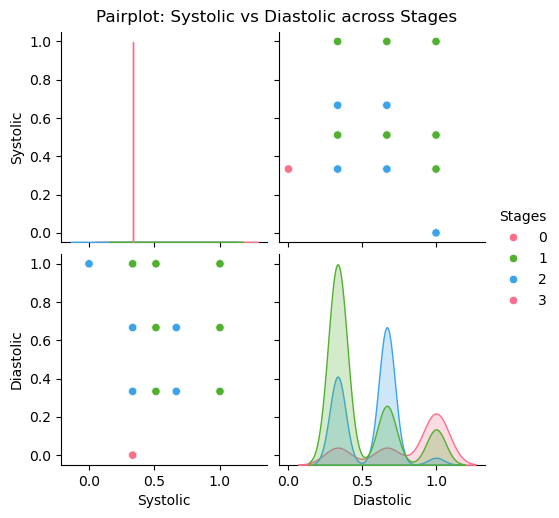

In [492]:
#Pairplot on numeric BP with Stages as hue
sns.pairplot(data[['Systolic', 'Diastolic', 'Stages']], hue='Stages', diag_kind="kde", palette="husl")
plt.suptitle("Pairplot: Systolic vs Diastolic across Stages", y=1.02)
plt.show()

In [493]:
data.head()

,Gender,Age,History,Patient,TakeMedication,Severity,BreathShortness,VisualChanges,NoseBleeding,Whendiagnoused,Systolic,Diastolic,ControlledDiet,Stages,Age_group
0,0,0.000,1,0,No,0.0,0,0,No,1.0,0.333333,0.333333,0,1,18-34
1,1,0.000,1,0,No,0.0,0,0,No,1.0,0.333333,0.333333,0,1,18-34
2,0,0.333,1,0,No,0.0,0,0,No,1.0,0.333333,0.333333,0,1,35-50
3,1,0.333,1,0,No,0.0,0,0,No,1.0,0.333333,0.333333,0,1,35-50
4,0,0.667,1,0,No,0.0,0,0,No,1.0,0.333333,0.333333,0,1,51-64


#DATA SPLITTING

In [494]:
data['TakeMedication'] = data['TakeMedication'].map({"No":0,"Yes":1})
data['NoseBleeding'] = data['NoseBleeding'].map({"No":0,"Yes":1})


data['NoseBleeding'] = data['NoseBleeding'].fillna(data['NoseBleeding'].mode()[0])
data['TakeMedication'] = data['TakeMedication'].fillna(data['TakeMedication'].mode()[0])
data['Severity'] = data['Severity'].fillna(data['Severity'].mode()[0])
data['Whendiagnoused'] = data['Whendiagnoused'].fillna(data['Whendiagnoused'].mode()[0])

In [495]:
data.drop('Age_group', axis=1, inplace=True)

In [496]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1348 entries, 0 to 1600
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Gender           1348 non-null   int64  
 1   Age              1348 non-null   float64
 2   History          1348 non-null   int64  
 3   Patient          1348 non-null   int64  
 4   TakeMedication   1348 non-null   float64
 5   Severity         1348 non-null   float64
 6   BreathShortness  1348 non-null   int64  
 7   VisualChanges    1348 non-null   int64  
 8   NoseBleeding     1348 non-null   float64
 9   Whendiagnoused   1348 non-null   float64
 10  Systolic         1348 non-null   float64
 11  Diastolic        1348 non-null   float64
 12  ControlledDiet   1348 non-null   int64  
 13  Stages           1348 non-null   int64  
dtypes: float64(7), int64(7)
memory usage: 158.0 KB


In [512]:
from sklearn.model_selection import train_test_split
x=data.drop(['Stages','Systolic','Diastolic'], axis=1)
y=data['Stages']
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [513]:
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
accuracy={}

In [514]:
data.head()

,Gender,Age,History,Patient,TakeMedication,Severity,BreathShortness,VisualChanges,NoseBleeding,Whendiagnoused,Systolic,Diastolic,ControlledDiet,Stages
0,0,0.000,1,0,0.0,0.0,0,0,1.0,1.0,0.333333,0.333333,0,1
1,1,0.000,1,0,0.0,0.0,0,0,1.0,1.0,0.333333,0.333333,0,1
2,0,0.333,1,0,0.0,0.0,0,0,1.0,1.0,0.333333,0.333333,0,1
3,1,0.333,1,0,0.0,0.0,0,0,1.0,1.0,0.333333,0.333333,0,1
4,0,0.667,1,0,0.0,0.0,0,0,1.0,1.0,0.333333,0.333333,0,1


In [515]:
log_reg = LogisticRegression(max_iter=1000)

log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)

print("Logistic Regression:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

accuracy['Logistic Regression'] = accuracy_score(y_test, y_pred)

Logistic Regression:
Accuracy: 0.9629629629629629
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.57      0.72        23
           1       0.92      1.00      0.96       113
           2       1.00      1.00      1.00        85
           3       1.00      1.00      1.00        49

    accuracy                           0.96       270
   macro avg       0.98      0.89      0.92       270
weighted avg       0.97      0.96      0.96       270

Confusion Matrix:
 [[ 13  10   0   0]
 [  0 113   0   0]
 [  0   0  85   0]
 [  0   0   0  49]]


In [516]:
decisionTree=DecisionTreeClassifier()
decisionTree.fit(X_train, y_train)
y_pred = decisionTree.predict(X_test)
print("Decision Tree:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
accuracy['Decision Tree']=accuracy_score(y_test, y_pred)

Decision Tree:
Accuracy: 0.9518518518518518
Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.61      0.68        23
           1       0.92      0.96      0.94       113
           2       1.00      1.00      1.00        85
           3       1.00      1.00      1.00        49

    accuracy                           0.95       270
   macro avg       0.93      0.89      0.91       270
weighted avg       0.95      0.95      0.95       270

Confusion Matrix:
 [[ 14   9   0   0]
 [  4 109   0   0]
 [  0   0  85   0]
 [  0   0   0  49]]


In [517]:
randomforest=RandomForestClassifier()
randomforest.fit(X_train, y_train)
y_pred = randomforest.predict(X_test)
print("Random Forest:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
accuracy['Random Forest']=accuracy_score(y_test, y_pred)

Random Forest:
Accuracy: 0.9592592592592593
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.57      0.70        23
           1       0.92      0.99      0.95       113
           2       1.00      1.00      1.00        85
           3       1.00      1.00      1.00        49

    accuracy                           0.96       270
   macro avg       0.96      0.89      0.91       270
weighted avg       0.96      0.96      0.96       270

Confusion Matrix:
 [[ 13  10   0   0]
 [  1 112   0   0]
 [  0   0  85   0]
 [  0   0   0  49]]


In [518]:
svm=SVC()
svm.fit(X_train, y_train)
y_pred = svm.predict(X_test)
print("SVM:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
accuracy['SVM'] = accuracy_score(y_test, y_pred)

SVM:
Accuracy: 0.9629629629629629
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.57      0.72        23
           1       0.92      1.00      0.96       113
           2       1.00      1.00      1.00        85
           3       1.00      1.00      1.00        49

    accuracy                           0.96       270
   macro avg       0.98      0.89      0.92       270
weighted avg       0.97      0.96      0.96       270

Confusion Matrix:
 [[ 13  10   0   0]
 [  0 113   0   0]
 [  0   0  85   0]
 [  0   0   0  49]]


In [519]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
print("KNN:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
accuracy['KNN']=accuracy_score(y_test, y_pred)

KNN:
Accuracy: 0.9481481481481482
Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.57      0.65        23
           1       0.92      0.96      0.94       113
           2       1.00      1.00      1.00        85
           3       1.00      1.00      1.00        49

    accuracy                           0.95       270
   macro avg       0.92      0.88      0.90       270
weighted avg       0.94      0.95      0.94       270

Confusion Matrix:
 [[ 13  10   0   0]
 [  4 109   0   0]
 [  0   0  85   0]
 [  0   0   0  49]]


In [520]:
RC=RidgeClassifier()
RC.fit(X_train, y_train)
y_pred = RC.predict(X_test)
print("RidgeClassifier:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
accuracy['RidgeClassifier']=accuracy_score(y_test, y_pred)


RidgeClassifier:
Accuracy: 0.9629629629629629
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.57      0.72        23
           1       0.92      1.00      0.96       113
           2       1.00      1.00      1.00        85
           3       1.00      1.00      1.00        49

    accuracy                           0.96       270
   macro avg       0.98      0.89      0.92       270
weighted avg       0.97      0.96      0.96       270

Confusion Matrix:
 [[ 13  10   0   0]
 [  0 113   0   0]
 [  0   0  85   0]
 [  0   0   0  49]]


In [521]:
naive_bayes=GaussianNB()
naive_bayes.fit(X_train, y_train)
y_pred = naive_bayes.predict(X_test)
print("Naive Bayes:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
accuracy['Naive Bayes']=accuracy_score(y_test, y_pred)


Naive Bayes:
Accuracy: 0.8
Classification Report:
               precision    recall  f1-score   support

           0       0.30      1.00      0.46        23
           1       1.00      0.52      0.69       113
           2       1.00      1.00      1.00        85
           3       1.00      1.00      1.00        49

    accuracy                           0.80       270
   macro avg       0.82      0.88      0.79       270
weighted avg       0.94      0.80      0.82       270

Confusion Matrix:
 [[23  0  0  0]
 [54 59  0  0]
 [ 0  0 85  0]
 [ 0  0  0 49]]
